In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

from sklearn.preprocessing import StandardScaler,MinMaxScaler
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

from sklearn.preprocessing import PolynomialFeatures
from itertools import combinations

from sklearn.preprocessing import RobustScaler

import xgboost as xgb
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from itertools import product
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, Lasso, BayesianRidge
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
import joblib

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from scipy.stats import loguniform, randint, uniform


In [76]:
data=pd.read_excel("data - copie.xlsx")
data = data.replace({',': '.'}, regex=True)
data.columns=['p','v','h','t','Ra','Desnity','VED','LED','PED']
X_selected=['p','v','h','t']
X = data[X_selected].values
y = data[['Ra']].values
data2=pd.read_excel('synthetic_data_gmm.xlsx')
data2 = data2.replace({',': '.'}, regex=True)

data2.columns=['p','v','h','t','Ra']

X2 = data2[X_selected].values
y2 = data2[['Ra']].values

In [57]:
data.head(20)

,p,v,h,t,Ra,Desnity,VED,LED,PED
0,150.0,400.0,115.0,25,5.20,99.63,130.434783,0.375000,3.260870
1,150.0,700.0,115.0,25,7.90,99.93,74.534161,0.214286,1.863354
2,150.0,1000.0,115.0,25,11.00,92.26,52.173913,0.150000,1.304348
3,180.0,400.0,115.0,25,5.00,99.91,156.521739,0.450000,3.913043
4,180.0,700.0,115.0,25,7.30,99.74,89.440994,0.257143,2.236025
5,180.0,1000.0,115.0,25,9.70,98.43,62.608696,0.180000,1.565217
6,200.0,400.0,115.0,25,4.60,99.53,173.913043,0.500000,4.347826
7,200.0,700.0,115.0,25,6.30,99.92,99.378882,0.285714,2.484472
8,200.0,1000.0,115.0,25,8.50,99.08,69.565217,0.200000,1.739130
9,180.4,821.6,72.2,20,11.57,98.31,152.057872,0.219572,3.041157


In [77]:
X_combined = np.vstack((X, X2))
y_combined = np.vstack((y, y2))


In [78]:
data_combined = pd.DataFrame(X_combined, columns=X_selected)
data_combined['Ra'] = y_combined
data_combined.to_csv("data_combined.csv")

In [5]:
def box_cox_fun(data, lambda_val=0.5):
    return ((data + 1e-5) ** lambda_val - 1) / lambda_val

def inverse_box_cox(data, lambda_val=0.5):
    if lambda_val == 0:
        return np.exp(data)
    else:
        return (data * lambda_val + 1) ** (1 / lambda_val) - 1e-5


In [6]:
data_extended = data_combined.copy()

data_extended['I(p^2)'] = data_extended['p']**2
data_extended['I(v^2)'] = data_extended['v']**2
data_extended['I(h^2)'] = data_extended['h']**2
data_extended['I(t^2)'] = data_extended['t']**2


data_extended['p:v'] = data_extended['p'] * data_extended['v']
data_extended['p:h'] = data_extended['p'] * data_extended['h']
data_extended['p:t'] = data_extended['p'] * data_extended['t']
data_extended['v:h'] = data_extended['v'] * data_extended['h']
data_extended['v:t'] = data_extended['v'] * data_extended['t']
data_extended['h:t'] = data_extended['h'] * data_extended['t']
data_extended['p:v:h'] = data_extended['p'] * data_extended['v'] * data_extended['h']
data_extended['p:v:t'] = data_extended['p'] * data_extended['v'] * data_extended['t']
data_extended['p:h:t'] = data_extended['p'] * data_extended['h'] * data_extended['t']
data_extended['v:h:t'] = data_extended['v'] * data_extended['h'] * data_extended['t']
data_extended['p:v:h:t'] = data_extended['p'] * data_extended['v'] * data_extended['h'] * data_extended['t']

variables = ['p', 'v', 'h', 't']

for var1, var2 in combinations(variables, 2):
    data_extended[f'I({var1}^2 * {var2})'] = (data_extended[var1]**2) * data_extended[var2]

for var1, var2, var3 in combinations(variables, 3):
    data_extended[f'I({var1}^2 * {var2} * {var3}^2)'] = (data_extended[var1]**2) * (data_extended[var2]) * (data_extended[var3]**2)

data_extended[f'I(p^2 * v^2 * h^2 * t^2)'] = (data_extended['p']**2) * (data_extended['v']**2) * (data_extended['h']**2) * (data_extended['t']**2)

data_extended['I(p^2 * v * h)'] = (data_extended['p']**2) * data_extended['v'] * (data_extended['h'])
data_extended['I(p * v^2 * h)'] = data_extended['p'] * (data_extended['v']) * (data_extended['h']**2)
data_extended['I(p^2 * v * h * t)'] = (data_extended['p']**2) * data_extended['v'] * data_extended['h'] * (data_extended['t'])


data_extended['I(sqrt(h)'] = np.sqrt(data_extended['h'])
data_extended['I(sqrt(v)'] = np.sqrt(data_extended['v'])
data_extended['I(sqrt(p)'] = np.sqrt(data_extended['p'])
data_extended['I(sqrt(t)'] = np.sqrt(data_extended['t'])

data_extended['I(sqrt(p) * v)'] = np.sqrt(data_extended['p']) * data_extended['v']
data_extended['I(sqrt(p) * h)'] = np.sqrt(data_extended['p']) * data_extended['h']
data_extended['I(sqrt(p) * t)'] = np.sqrt(data_extended['p']) * data_extended['t']

data_extended['I(sqrt(v) * p)'] = np.sqrt(data_extended['v']) * data_extended['p']
data_extended['I(sqrt(v) * h)'] = np.sqrt(data_extended['v']) * data_extended['h']
data_extended['I(sqrt(v) * t)'] = np.sqrt(data_extended['v']) * data_extended['t']

data_extended['I(sqrt(h) * p)'] = np.sqrt(data_extended['h']) * data_extended['p']
data_extended['I(sqrt(h) * v)'] = np.sqrt(data_extended['h']) * data_extended['v']
data_extended['I(sqrt(h) * t)'] = np.sqrt(data_extended['h']) * data_extended['t']

data_extended['I(sqrt(t) * p)'] = np.sqrt(data_extended['t']) * data_extended['p']
data_extended['I(sqrt(t) * v)'] = np.sqrt(data_extended['t']) * data_extended['v']
data_extended['I(sqrt(t) * h)'] = np.sqrt(data_extended['t']) * data_extended['h']

data_extended['I(p * sqrt(v))'] = data_extended['p'] * np.sqrt(data_extended['v'])
data_extended['I(sqrt(h) * t^2)'] = np.sqrt(data_extended['h']) * (data_extended['t']**2)
data_extended['I(p * h * sqrt(t))'] = data_extended['p'] * data_extended['h'] * np.sqrt(data_extended['t'])

data_extended['I(log(p) * v)'] = np.log(data_extended['p'] + 1e-6) * data_extended['v']
data_extended['I(log(p) * t)'] = np.log(data_extended['p'] + 1e-6) * data_extended['t']
data_extended['I(log(p) * h)'] = np.log(data_extended['p'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * p)'] = np.log(data_extended['v'] + 1e-6) * data_extended['p']
data_extended['I(log(v) * h)'] = np.log(data_extended['v'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * t)'] = np.log(data_extended['v'] + 1e-6) * data_extended['t']
data_extended['I(log(h) * p)'] = np.log(data_extended['h'] + 1e-6) * data_extended['p']
data_extended['I(log(h) * v)'] = np.log(data_extended['h'] + 1e-6) * data_extended['v']
data_extended['I(log(h) * t)'] = np.log(data_extended['h'] + 1e-6) * data_extended['t']
data_extended['I(log(t) * p)'] = np.log(data_extended['t'] + 1e-6) * data_extended['p']
data_extended['I(log(t) * h)'] = np.log(data_extended['t'] + 1e-6) * data_extended['h']
data_extended['I(log(t) * v)'] = np.log(data_extended['t'] + 1e-6) * data_extended['v']

In [9]:
from sklearn.feature_selection import f_regression
X = data_extended.drop(columns=['Ra'], errors='ignore')
scaler = RobustScaler()
X_standardized = scaler.fit_transform(X)

X_standardized = pd.DataFrame(X_standardized, columns=X.columns)

y = data_combined['Ra']
f_scores, p_values = f_regression(X_standardized, y)
anova_results = pd.DataFrame({'Variable': X_standardized.columns, 'F-Score': f_scores, 'p-value': p_values})
significant_vars = anova_results[anova_results['p-value'] < 0.05]
significant_vars = significant_vars.sort_values(by='F-Score', ascending=False)
print(significant_vars)

                    Variable     F-Score       p-value
24                I(h^2 * t)  224.920108  9.750999e-44
13                       h:t  178.899954  4.051209e-36
48            I(sqrt(t) * h)  142.698371  8.278351e-30
45            I(sqrt(h) * t)  129.226266  2.209446e-27
50          I(sqrt(h) * t^2)  128.410490  3.109101e-27
62             I(log(t) * h)  110.234809  6.947182e-24
60             I(log(h) * t)   93.481011  1.015283e-20
6                     I(h^2)   92.034758  1.920607e-20
16                     p:h:t   79.699949  4.669920e-18
7                     I(t^2)   74.327004  5.282097e-17
3                          t   70.574306  2.910253e-16
51        I(p * h * sqrt(t))   68.209684  8.574684e-16
36                 I(sqrt(t)   66.631284  1.767965e-15
2                          h   62.061826  1.451631e-14
54             I(log(p) * h)   61.937473  1.537579e-14
53             I(log(p) * t)   57.961980  9.733011e-14
38            I(sqrt(p) * h)   56.456700  1.963895e-13
57        

In [10]:
from sklearn.feature_selection import mutual_info_regression
X = data_extended.drop(columns=['Ra'], errors='ignore')
scaler = RobustScaler()
X_standardized = scaler.fit_transform(X)

X_standardized = pd.DataFrame(X_standardized, columns=X.columns)
y = data_extended['Ra']

mi_scores = mutual_info_regression(X_standardized, y)

mi_results = pd.DataFrame({'Variable': X_standardized.columns, 'MI Score': mi_scores})

mi_results = mi_results.sort_values(by='MI Score', ascending=False)

print("\nScores d'Information Mutuelle :")
print(mi_results)

top_features = mi_results.head(10)['Variable']
print("\nTop 10 des variables les plus significatives selon l'information mutuelle :")
print(top_features)

X_selected = X[top_features]



Scores d'Information Mutuelle :
                    Variable  MI Score
53             I(log(p) * t)  0.563627
30            I(p^2 * v * h)  0.511691
58             I(log(h) * p)  0.498916
13                       h:t  0.498153
17                     v:h:t  0.489529
..                       ...       ...
29  I(p^2 * v^2 * h^2 * t^2)  0.282147
23                I(v^2 * t)  0.272721
44            I(sqrt(h) * v)  0.266037
37            I(sqrt(p) * v)  0.256899
22                I(v^2 * h)  0.249787

[64 rows x 2 columns]

Top 10 des variables les plus significatives selon l'information mutuelle :
53       I(log(p) * t)
30      I(p^2 * v * h)
58       I(log(h) * p)
13                 h:t
17               v:h:t
60       I(log(h) * t)
16               p:h:t
39      I(sqrt(p) * t)
25    I(p^2 * v * h^2)
50    I(sqrt(h) * t^2)
Name: Variable, dtype: object


In [11]:
from sklearn.feature_selection import f_regression, mutual_info_regression

X = data_extended.drop(columns=['Ra'], errors='ignore')

scaler = RobustScaler()
X_standardized = scaler.fit_transform(X)
X_standardized = pd.DataFrame(X_standardized, columns=X.columns)
y = data_extended['Ra']

f_scores, p_values = f_regression(X_standardized, y)
anova_results = pd.DataFrame({
    'Variable': X_standardized.columns,
    'F-Score': f_scores,
    'p-value': p_values
})

anova_significant = anova_results[anova_results['p-value'] < 0.05]['Variable'].tolist()

mi_scores = mutual_info_regression(X_standardized, y)
mi_results = pd.DataFrame({
    'Variable': X_standardized.columns,
    'MI-Score': mi_scores
})

threshold = 0.1
mi_significant = mi_results[mi_results['MI-Score'] > threshold]['Variable'].tolist()

selected_vars = list(set(anova_significant) & set(mi_significant))

X_selected_vars = X[selected_vars]

print("Variables sélectionnées (communes entre ANOVA et Information Mutuelle) :")
print(selected_vars)


Variables sélectionnées (communes entre ANOVA et Information Mutuelle) :
['I(log(t) * h)', 'I(sqrt(v) * p)', 'I(p^2 * v * t^2)', 'I(h^2)', 'I(sqrt(h) * t)', 'I(p^2 * h * t^2)', 'I(sqrt(p) * t)', 'I(p^2)', 'I(t^2)', 'h:t', 'v', 'I(p * v^2 * h)', 'I(sqrt(h)', 'v:h:t', 't', 'I(p^2 * v^2 * h^2 * t^2)', 'I(sqrt(h) * v)', 'I(v^2 * h * t^2)', 'I(sqrt(t)', 'I(log(h) * t)', 'I(p * h * sqrt(t))', 'I(sqrt(h) * t^2)', 'p:h:t', 'I(sqrt(p)', 'I(log(v) * h)', 'I(sqrt(t) * p)', 'I(p^2 * v * h * t)', 'I(log(p) * h)', 'I(h^2 * t)', 'I(log(v) * p)', 'I(log(h) * v)', 'I(p * sqrt(v))', 'p:v:h:t', 'I(p^2 * t)', 'I(sqrt(v) * h)', 'I(sqrt(v) * t)', 'I(p^2 * h)', 'I(sqrt(p) * h)', 'p:h', 'p:v:t', 'I(sqrt(t) * h)', 'I(log(p) * t)', 'I(log(v) * t)', 'I(sqrt(v)', 'I(p^2 * v * h^2)', 'p:v:h', 'I(log(h) * p)', 'I(v^2 * h)', 'I(log(t) * p)', 'I(p^2 * v * h)', 'I(v^2)', 'p', 'I(p^2 * v)', 'I(sqrt(h) * p)', 'I(log(t) * v)', 'I(log(p) * v)', 'p:t', 'h']


In [12]:
corr_matrix = X_selected_vars.corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

X_filtered = X_selected_vars.drop(columns=to_drop)

print(f"Variables supprimées car trop corrélées: {to_drop}")
print(f"Nombre de variables restantes: {X_filtered.shape[1]}")

Variables supprimées car trop corrélées: ['I(h^2)', 'I(p^2 * h * t^2)', 'I(sqrt(p) * t)', 'I(p^2)', 'I(t^2)', 'h:t', 'I(sqrt(h)', 't', 'I(p^2 * v^2 * h^2 * t^2)', 'I(sqrt(h) * v)', 'I(v^2 * h * t^2)', 'I(sqrt(t)', 'I(log(h) * t)', 'I(sqrt(h) * t^2)', 'p:h:t', 'I(sqrt(p)', 'I(log(v) * h)', 'I(sqrt(t) * p)', 'I(p^2 * v * h * t)', 'I(log(p) * h)', 'I(h^2 * t)', 'I(log(v) * p)', 'I(log(h) * v)', 'I(p * sqrt(v))', 'p:v:h:t', 'I(p^2 * t)', 'I(sqrt(v) * h)', 'I(sqrt(v) * t)', 'I(p^2 * h)', 'I(sqrt(p) * h)', 'p:h', 'p:v:t', 'I(sqrt(t) * h)', 'I(log(p) * t)', 'I(log(v) * t)', 'I(sqrt(v)', 'I(p^2 * v * h^2)', 'p:v:h', 'I(log(h) * p)', 'I(v^2 * h)', 'I(log(t) * p)', 'I(p^2 * v * h)', 'I(v^2)', 'p', 'I(p^2 * v)', 'I(sqrt(h) * p)', 'I(log(t) * v)', 'I(log(p) * v)', 'p:t', 'h']
Nombre de variables restantes: 8


In [22]:
X_selected=["p","v","h","t","I(p^2)","p:h:t","v:h:t","I(t^2)","I(sqrt(p) * h)","I(h^2)"]
X=data_extended[X_selected].values
scaler=RobustScaler()
X_scaled =scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_combined, 
    test_size=0.20, 
    random_state=42,shuffle=True)
y_train_bc=box_cox_fun(y_train)

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor



def objective(trial):
   
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 30, step=1),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20, step=1),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10, step=1),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False])
    }
    
    
    rf = RandomForestRegressor(**params)
    rf.fit(X_train, y_train_bc.ravel())
    
    y_pred_bc_rf = rf.predict(X_test)
    y_pred_rf = inverse_box_cox(y_pred_bc_rf)
    
    
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    
    
    return rmse_rf


study = optuna.create_study(direction="minimize")  
study.optimize(objective, n_trials=100)  


print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


[I 2025-04-28 16:24:17,506] A new study created in memory with name: no-name-362906ab-2aaa-4127-bac7-76c6d92d724e
[I 2025-04-28 16:24:20,065] Trial 0 finished with value: 2.778116171548521 and parameters: {'n_estimators': 900, 'max_depth': 25, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 2.778116171548521.
[I 2025-04-28 16:24:20,204] Trial 1 finished with value: 3.0345655726523173 and parameters: {'n_estimators': 100, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 2.778116171548521.
[I 2025-04-28 16:24:21,020] Trial 2 finished with value: 2.7840683378987245 and parameters: {'n_estimators': 600, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 2.778116171548521.
[I 2025-04-28 16:24:21,437] Trial 3 finished with value: 2.7120754524878032

Best trial:
FrozenTrial(number=43, state=TrialState.COMPLETE, values=[2.604048264978481], datetime_start=datetime.datetime(2025, 4, 28, 16, 25, 19, 154457), datetime_complete=datetime.datetime(2025, 4, 28, 16, 25, 21, 23901), params={'n_estimators': 900, 'max_depth': 29, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=100), 'max_depth': IntDistribution(high=30, log=False, low=5, step=1), 'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None)), 'bootstrap': CategoricalDistribution(choices=(True, False))}, trial_id=43, value=None)
Best params:
{'n_estimators': 900, 'max_depth': 29, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'

In [ ]:

rf = RandomForestRegressor(bootstrap= False, max_depth= 29, max_features='sqrt', min_samples_leaf= 1, min_samples_split= 2, n_estimators= 900)


rf.fit(X_train, y_train_bc.ravel())
y_pred_bc_rf = rf.predict(X_test)
y_pred_rf = inverse_box_cox(y_pred_bc_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
print(f"R2: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"mape: {mape_rf:.4f}")

R2: 0.7249
RMSE: 2.6316
MAE: 1.5902
mape: 53.4925


In [50]:

from catboost import CatBoostRegressor


def objective(trial):
    
    params = {
        'iterations': trial.suggest_int('iterations', 1000, 5000, step=500),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 0.1),
        'depth': trial.suggest_int('depth', 4, 12),
        'loss_function': 'RMSE',
        'verbose': 0
    }
    
    
    cat_model = CatBoostRegressor(**params)
    cat_model.fit(X_train, y_train_bc)
    
    
    y_pred_cat_bc = cat_model.predict(X_test)
    y_pred_cat = inverse_box_cox(y_pred_cat_bc)
    
    
    rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
    
    
    return rmse_cat


study = optuna.create_study(direction="minimize")  
study.optimize(objective, n_trials=50)  

print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


[I 2025-04-28 16:30:24,092] A new study created in memory with name: no-name-1a1bc1f6-d957-4bfd-b7ac-8f7a09b01f5a
C:\Users\hrouabah\AppData\Local\Temp\ipykernel_4620\3198540404.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 0.1),
[I 2025-04-28 16:30:44,538] Trial 0 finished with value: 4.961531217364148 and parameters: {'iterations': 3000, 'learning_rate': 1.7823146762433876e-05, 'depth': 8}. Best is trial 0 with value: 4.961531217364148.
C:\Users\hrouabah\AppData\Local\Temp\ipykernel_4620\3198540404.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learnin

KeyboardInterrupt: 

In [55]:


cat_model = CatBoostRegressor(
    iterations=3500,
    learning_rate=0.03775618511372227,
    depth=11,
    loss_function='RMSE',
    verbose=0,
   
)

cat_model.fit(X_train, y_train_bc)

y_pred_cat_bc = cat_model.predict(X_test)
y_pred_cat=inverse_box_cox(y_pred_cat_bc)

r2_cat = r2_score(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mape_cat = np.mean(np.abs((y_test - y_pred_cat) / y_test)) * 100
print(f"R2: {r2_cat:.4f}")
print(f"RMSE: {rmse_cat:.4f}")
print(f"MAE: {mae_cat:.4f}")
print(f"MAPE: {mape_cat:.4f}")

R2: 0.8116
RMSE: 2.1775
MAE: 1.3992
MAPE: 53.6618


In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform


param_dist = {
    'max_depth': randint(3, 12),
    'learning_rate': loguniform(1e-4, 0.1),
    'n_estimators': randint(200, 1000),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.3),
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0, 0.5),
    'scale_pos_weight': uniform(1, 2),
    'max_delta_step': randint(1, 10),
    'min_split_loss': uniform(0, 0.3)
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    early_stopping_rounds=50, 
    eval_metric='rmse'
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=3000,               
    cv=5,                     
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train, y_train_bc,
    test_size=0.15,
    random_state=42
)

random_search.fit(
    X_train_part, y_train_part,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_model = random_search.best_estimator_
print(best_model)
y_pred = best_model.predict(X_test)
y_pred_original = inverse_box_cox(y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_original))
mae_xgb = mean_absolute_error(y_test, y_pred_original)
r2_xgb = r2_score(y_test, y_pred_original)

print(f"R2: {r2_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")


Fitting 5 folds for each of 3000 candidates, totalling 15000 fits
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8449882854898976, device=None,
             early_stopping_rounds=50, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.11483523012091217, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03291848383642703,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=4, max_depth=6, max_leaves=None, min_child_weight=3,
             min_split_loss=0.018612425086966287, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=756,
             n_jobs=-1, ...)
R2: 0.6961
RMSE: 2.7659
MAE: 1.8299


In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, PReLU
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, AdamW
from tensorflow.keras.callbacks import EarlyStopping



y_test_bc = box_cox_fun(y_test)


def get_optimizer(optimizer_name, learning_rate):
    optimizers_dict = {
        'adam': Adam(learning_rate=learning_rate),
        'adamw': AdamW(learning_rate=learning_rate, weight_decay=1e-4),
        'sgd': SGD(learning_rate=learning_rate),
        'rmsprop': RMSprop(learning_rate=learning_rate),
    }
    
    if optimizer_name.lower() not in optimizers_dict:
        raise ValueError(f"Optimiseur '{optimizer_name}' non supporté ! Choisis parmi {list(optimizers_dict.keys())}")
    
    return optimizers_dict[optimizer_name.lower()]

def build_model(input_dim, optimizer_name, learning_rate):
    opt = get_optimizer(optimizer_name, learning_rate)
    
    model = Sequential([
        Dense(256, input_dim=input_dim),
        BatchNormalization(),
        PReLU(),

        Dense(128),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(64),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(32),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(16),
        BatchNormalization(),
        PReLU(),
        Dropout(0.2),

        Dense(1, activation='linear')
    ])
    
    model.compile(optimizer=opt, loss=tf.keras.losses.Huber(delta=1.0), metrics=['mae'])
    return model


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)


optimizers = ['adam', 'adamw', 'sgd', 'rmsprop']
learning_rates = [0.001, 0.005, 0.01]
batch_sizes = [16, 32]


best_score = float('inf')
best_params = {}
best_model = None
results = []


for opt_name in optimizers:
    for lr in learning_rates:
        for bs in batch_sizes:
            print(f"\n🔵 Test: optimizer={opt_name}, learning_rate={lr}, batch_size={bs}")
            
            model = build_model(X_train.shape[1], opt_name, lr)
            
            history = model.fit(
                X_train, y_train_bc,
                epochs=1000,
                batch_size=bs,
                validation_data=(X_test, y_test_bc),
                verbose=0,
                callbacks=[early_stopping]
            )
            
            preds = model.predict(X_test).squeeze()
            preds = inverse_box_cox(preds)
            
            rmse = np.sqrt(mean_squared_error(y_test, preds))
            mae = mean_absolute_error(y_test, preds)
            r2 = r2_score(y_test, preds)
            
           
            results.append({
                'optimizer': opt_name,
                'learning_rate': lr,
                'batch_size': bs,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2
            })
            
           
            if rmse < best_score:
                best_score = rmse
                best_params = {'optimizer': opt_name, 'learning_rate': lr, 'batch_size': bs}
                best_model = model


results_df = pd.DataFrame(results)
print("\n📊 Résumé de tous les tests :")
print(results_df.sort_values('RMSE'))


print("\n✅ Meilleurs hyperparamètres trouvés :")
print(best_params)
print(f"RMSE: {best_score:.4f}")


y_pred_final = best_model.predict(X_test)
y_pred_final = inverse_box_cox(y_pred_final)

print("\n📈 Résultats finaux sur le test set :")
print(f"R2 : {r2_score(y_test, y_pred_final):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}")



🔵 Test: optimizer=adam, learning_rate=0.001, batch_size=16
4/4 [==============================] - 0s 5ms/step

🔵 Test: optimizer=adam, learning_rate=0.001, batch_size=32
4/4 [==============================] - 0s 7ms/step

🔵 Test: optimizer=adam, learning_rate=0.005, batch_size=16
4/4 [==============================] - 0s 7ms/step

🔵 Test: optimizer=adam, learning_rate=0.005, batch_size=32
4/4 [==============================] - 0s 8ms/step

🔵 Test: optimizer=adam, learning_rate=0.01, batch_size=16
4/4 [==============================] - 0s 6ms/step

🔵 Test: optimizer=adam, learning_rate=0.01, batch_size=32
4/4 [==============================] - 1s 7ms/step

🔵 Test: optimizer=adamw, learning_rate=0.001, batch_size=16
4/4 [==============================] - 0s 7ms/step

🔵 Test: optimizer=adamw, learning_rate=0.001, batch_size=32
4/4 [==============================] - 0s 7ms/step

🔵 Test: optimizer=adamw, learning_rate=0.005, batch_size=16
4/4 [==============================] - 0s 7ms/step


Fitting 5 folds for each of 150 candidates, totalling 750 fits

--- Meilleur SVR trouvé ---
Best params: {'C': 5, 'epsilon': 0.05, 'gamma': 1, 'kernel': 'rbf'}
R2: 0.7452
RMSE: 2.5326
MAE: 1.5949
MAPE: 54.61%


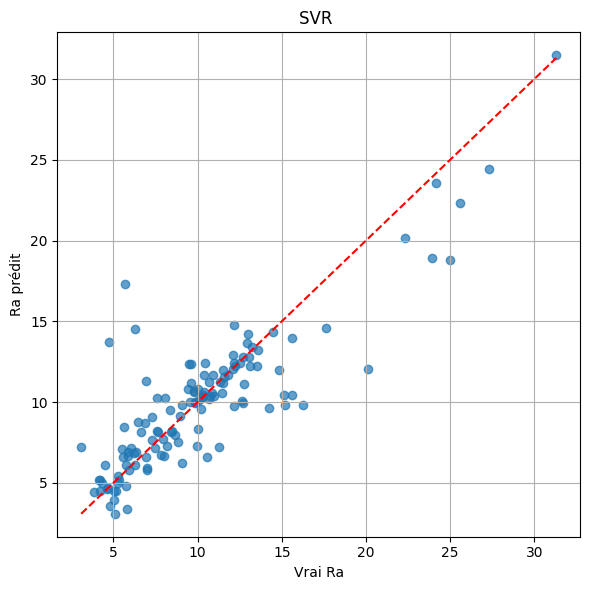

In [37]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    'C': [0.1,0.5, 1,5,10],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    'kernel': ['rbf'],
     
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

svr = SVR()
grid_svr = GridSearchCV(
    svr,
    param_grid=param_grid_svr,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

grid_svr.fit(X_train, y_train_bc.ravel())
best_svr = grid_svr.best_estimator_


y_pred_bc_svr = best_svr.predict(X_test)
y_pred_svr = inverse_box_cox(y_pred_bc_svr)


rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
mape_svr = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100

print("\n--- Meilleur SVR trouvé ---")
print(f"Best params: {grid_svr.best_params_}")
print(f"R2: {r2_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"MAE: {mae_svr:.4f}")
print(f"MAPE: {mape_svr:.2f}%")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Vrai Ra")
plt.ylabel("Ra prédit")
plt.title("SVR ")
plt.grid(True)
plt.tight_layout()
plt.show()


In [38]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
y_test_bc=box_cox_fun(y_test)

tabnet_model = TabNetRegressor(
    n_d=64,  
    n_a=64,  
    n_steps=5,  
    gamma=1.5,  
    lambda_sparse=1e-5, 
    optimizer_fn=torch.optim.Adam,  
    optimizer_params=dict(lr=1e-2), 
    mask_type='sparsemax'  
)


tabnet_model.fit(
    X_train, 
    y_train_bc,  
    eval_set=[(X_test, y_test_bc)],
    batch_size=32,  
    max_epochs=500, 
    patience=30,  
    virtual_batch_size=16, 
    num_workers=1  
)


y_pred_tabnet_bc = tabnet_model.predict(X_test)
y_pred_tabnet = inverse_box_cox(y_pred_tabnet_bc) 


r2_tabnet = r2_score(y_test, y_pred_tabnet)
rmse_tabnet = np.sqrt(mean_squared_error(y_test, y_pred_tabnet))
mae_tabnet = mean_absolute_error(y_test, y_pred_tabnet)
mape_tabnet = np.mean(np.abs((y_test - y_pred_tabnet) / y_test)) * 100

print(f"R2: {r2_tabnet:.4f}")
print(f"RMSE: {rmse_tabnet:.4f}")
print(f"MAE: {mae_tabnet:.4f}")
print(f"MAPE: {mape_tabnet:.4f}")


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 7.56137 | val_0_mse: 26.48594|  0:00:09s
epoch 1  | loss: 4.67876 | val_0_mse: 7.12192 |  0:00:16s
epoch 2  | loss: 2.81715 | val_0_mse: 3.1893  |  0:00:23s
epoch 3  | loss: 2.45286 | val_0_mse: 2.56948 |  0:00:30s
epoch 4  | loss: 2.49074 | val_0_mse: 2.67932 |  0:00:37s
epoch 5  | loss: 1.97849 | val_0_mse: 2.28843 |  0:00:44s
epoch 6  | loss: 1.90295 | val_0_mse: 1.81164 |  0:00:51s
epoch 7  | loss: 2.05178 | val_0_mse: 2.05981 |  0:00:59s
epoch 8  | loss: 1.80409 | val_0_mse: 1.95621 |  0:01:06s
epoch 9  | loss: 1.81913 | val_0_mse: 2.36879 |  0:01:13s
epoch 10 | loss: 1.62604 | val_0_mse: 1.72382 |  0:01:20s
epoch 11 | loss: 1.68397 | val_0_mse: 1.74448 |  0:01:27s
epoch 12 | loss: 1.65014 | val_0_mse: 2.09424 |  0:01:35s
epoch 13 | loss: 1.55659 | val_0_mse: 1.37772 |  0:01:42s
epoch 14 | loss: 1.69171 | val_0_mse: 4.56323 |  0:01:49s
epoch 15 | loss: 1.55656 | val_0_mse: 2.90302 |  0:01:56s
epoch 16 | loss: 1.70317 | val_0_mse: 1.6929  |  0:02:03s
epoch 17 | los

c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


R2: 0.5702
RMSE: 3.2890
MAE: 2.4442
MAPE: 27.9032


In [39]:
import optuna
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
from sklearn.metrics import mean_squared_error
import numpy as np



def objective(trial):
    params = {
        'n_d': trial.suggest_categorical('n_d', [32, 64, 128, 256]),
        'n_a': trial.suggest_categorical('n_a', [32, 64, 128, 256]),
        'n_steps': trial.suggest_int('n_steps', 3, 10),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-7, 1e-3, log=True),
        'optimizer_fn': torch.optim.Adam,
        'optimizer_params': dict(lr=trial.suggest_float('lr', 1e-4, 1e-2, log=True)),
        'mask_type': trial.suggest_categorical('mask_type', ['sparsemax', 'entmax']),
        'scheduler_params': {"step_size":50, "gamma":0.9},
        'scheduler_fn': torch.optim.lr_scheduler.StepLR,
        'verbose': 0,
    }
    
    model = TabNetRegressor(**params)
    
    model.fit(
        X_train=X_train,
        y_train=y_train_bc,
        eval_set=[(X_test, y_test_bc)],
        eval_metric=['rmse'],
        patience=30,
        max_epochs=300,
        batch_size=32,
        virtual_batch_size=16,
        num_workers=0
    )
    
    preds = model.predict(X_test)
    score = np.sqrt(mean_squared_error(y_test_bc, preds)) 
    
    return score 


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50) 


print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-04-28 14:39:30,219] A new study created in memory with name: no-name-f024a81d-c194-4be9-b716-3a88200b1390



Early stopping occurred at epoch 144 with best_epoch = 114 and best_val_0_rmse = 0.86437


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-04-28 14:43:32,415] Trial 0 finished with value: 0.8643709012603343 and parameters: {'n_d': 256, 'n_a': 256, 'n_steps': 4, 'gamma': 1.756571931434836, 'lambda_sparse': 1.612817858235398e-06, 'lr': 0.0024542677195665856, 'mask_type': 'sparsemax'}. Best is trial 0 with value: 0.8643709012603343.



Early stopping occurred at epoch 212 with best_epoch = 182 and best_val_0_rmse = 0.67782


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-04-28 14:45:33,146] Trial 1 finished with value: 0.6778215122109699 and parameters: {'n_d': 64, 'n_a': 64, 'n_steps': 3, 'gamma': 1.0700983336962633, 'lambda_sparse': 4.3051872224454867e-07, 'lr': 0.0061677668397012225, 'mask_type': 'sparsemax'}. Best is trial 1 with value: 0.6778215122109699.


...


Early stopping occurred at epoch 203 with best_epoch = 173 and best_val_0_rmse = 0.79421

Early stopping occurred at epoch 106 with best_epoch = 76 and best_val_0_rmse = 0.94237


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-04-28 16:04:11,403] Trial 48 finished with value: 0.9423719533320618 and parameters: {'n_d': 64, 'n_a': 256, 'n_steps': 7, 'gamma': 1.1268456975544514, 'lambda_sparse': 3.0297403843564916e-07, 'lr': 0.0027943499979754655, 'mask_type': 'entmax'}. Best is trial 31 with value: 0.6575377849319705.



Early stopping occurred at epoch 176 with best_epoch = 146 and best_val_0_rmse = 0.92696


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-04-28 16:07:05,411] Trial 49 finished with value: 0.9269562528282432 and parameters: {'n_d': 256, 'n_a': 64, 'n_steps': 5, 'gamma': 1.7212190084141534, 'lambda_sparse': 5.940291875682802e-07, 'lr': 0.0015894222190143514, 'mask_type': 'sparsemax'}. Best is trial 31 with value: 0.6575377849319705.


Best trial:
FrozenTrial(number=31, state=TrialState.COMPLETE, values=[0.6575377849319705], datetime_start=datetime.datetime(2025, 4, 28, 15, 35, 6, 452250), datetime_complete=datetime.datetime(2025, 4, 28, 15, 37, 51, 197516), params={'n_d': 64, 'n_a': 128, 'n_steps': 5, 'gamma': 1.0376275312412115, 'lambda_sparse': 1.2891920427319046e-07, 'lr': 0.007427462676788047, 'mask_type': 'entmax'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_d': CategoricalDistribution(choices=(32, 64, 128, 256)), 'n_a': CategoricalDistribution(choices=(32, 64, 128, 256)), 'n_steps': IntDistribution(high=10, log=False, low=3, step=1), 'gamma': FloatDistribution(high=2.0, log=False, low=1.0, step=None), 'lambda_sparse': FloatDistribution(high=0.001, log=True, low=1e-07, step=None), 'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'mask_type': CategoricalDistribution(choices=('sparsemax', 'entmax'))}, trial_id=31, value=None)
Best params:
{'n_d': 64, 'n_a': 128, 

In [ ]:
tabnet_model = TabNetRegressor(
    n_d=64,
    n_a=128,
    n_steps=5,
    gamma=1.0376,
    lambda_sparse=1.289e-07,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.0074),
    mask_type='entmax'
)


tabnet_model.fit(
    X_train,
    y_train_bc,
    eval_set=[(X_test, y_test_bc)],
    eval_metric=['rmse'],
    patience=30,
    max_epochs=300,
    batch_size=32,
    virtual_batch_size=16,
    num_workers=0
)

y_pred_tabnet_bc = tabnet_model.predict(X_test)
y_pred_tabnet = inverse_box_cox(y_pred_tabnet_bc)


r2_tabnet = r2_score(y_test, y_pred_tabnet)
rmse_tabnet = np.sqrt(mean_squared_error(y_test, y_pred_tabnet))
mae_tabnet = mean_absolute_error(y_test, y_pred_tabnet)
mape_tabnet = np.mean(np.abs((y_test - y_pred_tabnet) / y_test)) * 100

print(f"R2: {r2_tabnet:.4f}")
print(f"RMSE: {rmse_tabnet:.4f}")
print(f"MAE: {mae_tabnet:.4f}")
print(f"MAPE: {mape_tabnet:.4f}")


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 7.28554 | val_0_rmse: 2.68961 |  0:00:00s
epoch 1  | loss: 4.74284 | val_0_rmse: 3.00752 |  0:00:01s
epoch 2  | loss: 3.64368 | val_0_rmse: 1.7102  |  0:00:01s
epoch 3  | loss: 2.81997 | val_0_rmse: 1.76162 |  0:00:02s
epoch 4  | loss: 3.26551 | val_0_rmse: 1.81213 |  0:00:03s
epoch 5  | loss: 2.2406  | val_0_rmse: 1.39815 |  0:00:03s
epoch 6  | loss: 2.30208 | val_0_rmse: 1.65235 |  0:00:04s
epoch 7  | loss: 2.01385 | val_0_rmse: 1.79969 |  0:00:04s
epoch 8  | loss: 1.64243 | val_0_rmse: 1.22051 |  0:00:05s
epoch 9  | loss: 1.77619 | val_0_rmse: 1.4241  |  0:00:05s
epoch 10 | loss: 1.57401 | val_0_rmse: 1.38415 |  0:00:06s
epoch 11 | loss: 1.47873 | val_0_rmse: 1.27996 |  0:00:07s
epoch 12 | loss: 1.53885 | val_0_rmse: 1.28805 |  0:00:07s
epoch 13 | loss: 1.48965 | val_0_rmse: 1.71728 |  0:00:08s
epoch 14 | loss: 1.52624 | val_0_rmse: 1.29111 |  0:00:08s
epoch 15 | loss: 1.67014 | val_0_rmse: 1.20398 |  0:00:09s
epoch 16 | loss: 1.48211 | val_0_rmse: 1.3963  |  0:00:1

c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


R2: 0.6686
RMSE: 2.8881
MAE: 2.0225
MAPE: 21.0306


In [42]:
from sklearn.tree import DecisionTreeRegressor

param_grid = {
    'max_depth': [4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}


grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train, y_train_bc.ravel())


best_tree = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)


y_pred_bc_tree = best_tree.predict(X_test)
y_pred_tree = inverse_box_cox(y_pred_bc_tree)




rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
mape_tree = np.mean(np.abs((y_test - y_pred_tree) / y_test)) * 100

print("\n--- Decision Tree ---")
print(f"R2: {r2_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")
print(f"MAE: {mae_tree:.4f}")
print(f"MAPE: {mape_tree:.2f}%")




Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best hyperparameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}

--- Decision Tree ---
R2: 0.6012
RMSE: 3.1683
MAE: 1.8549
MAPE: 55.11%


In [43]:
from sklearn.linear_model import BayesianRidge


bayes = BayesianRidge(alpha_1=1e-6, alpha_2=1e-6, lambda_1=1e-6, lambda_2=1e-6)

bayes.fit(X_train, y_train_bc.ravel())
y_pred_bc_bayes = bayes.predict(X_test)
y_pred_bayes = inverse_box_cox(y_pred_bc_bayes)


rmse_bayes = np.sqrt(mean_squared_error(y_test, y_pred_bayes))
mae_bayes = mean_absolute_error(y_test, y_pred_bayes)
r2_bayes = r2_score(y_test, y_pred_bayes)
mape_bayes = np.mean(np.abs((y_test - y_pred_bayes) / y_test)) * 100

print("\n--- Bayesian Ridge ---")
print(f"R2: {r2_bayes:.4f}")
print(f"RMSE: {rmse_bayes:.4f}")
print(f"MAE: {mae_bayes:.4f}")
print(f"MAPE: {mape_bayes:.2f}%")




--- Bayesian Ridge ---
R2: 0.1598
RMSE: 4.5985
MAE: 3.5270
MAPE: 47.33%


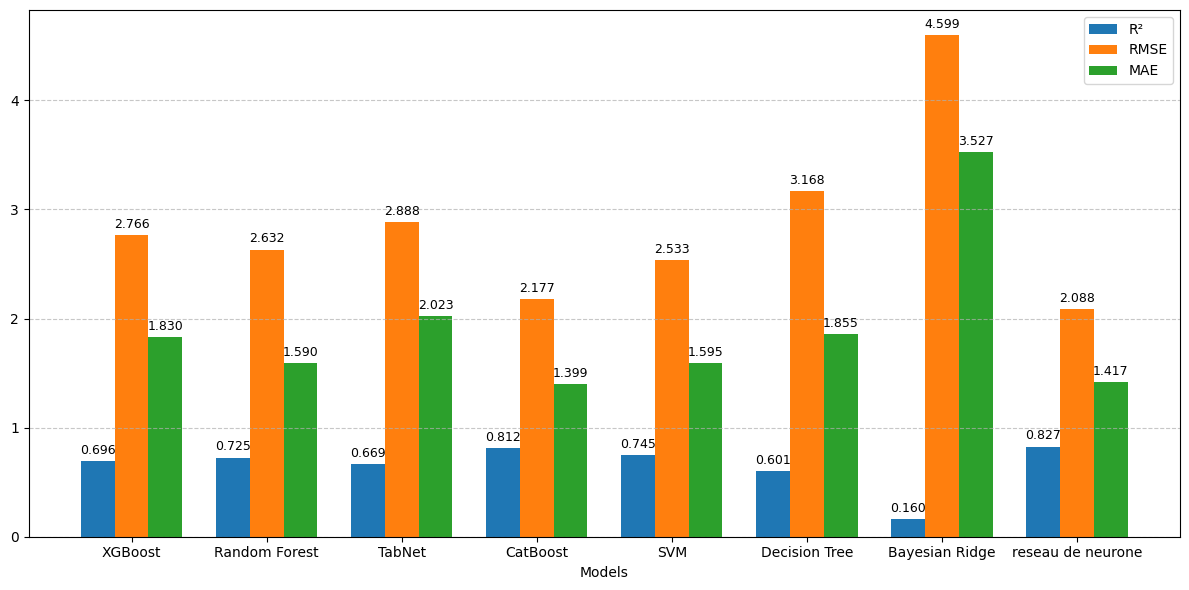

In [56]:
r2_rn = 0.8268
mae_rn = 1.4166
rmse_rn = 2.0878
models = ['XGBoost', 'Random Forest', 'TabNet', 'CatBoost', 'SVM', 'Decision Tree', 'Bayesian Ridge','reseau de neurone']


r2_scores = [r2_xgb, r2_rf, r2_tabnet, r2_cat, r2_svr, r2_tree, r2_bayes,r2_rn]
rmse_scores = [rmse_xgb, rmse_rf, rmse_tabnet, rmse_cat, rmse_svr, rmse_tree, rmse_bayes,rmse_rn]
mae_scores = [mae_xgb, mae_rf, mae_tabnet, mae_cat, mae_svr, mae_tree, mae_bayes,mae_rn]


x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, r2_scores, width, label='R²')
bars2 = ax.bar(x, rmse_scores, width, label='RMSE')
bars3 = ax.bar(x + width, mae_scores, width, label='MAE')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

ax.set_xlabel('Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()


In [72]:
import joblib


joblib.dump(rf, 'models_pvht_anova_gmm/rf_model.pkl')
cat_model.save_model("models_pvht_anova_gmm/catboost_model.cbm")
best_model.save("models_pvht_anova_gmm/best_keras_model.h5")
joblib.dump(best_svr, 'models_pvht_anova_gmm/svr_model.pkl')
tabnet_model.save_model('models_pvht_anova_gmm/tabnet_model.zip')
joblib.dump(best_tree, 'models_pvht_anova_gmm/decision_tree_model.pkl')

Successfully saved model at models_pvht_anova_gmm/tabnet_model.zip.zip


['models_pvht_anova_gmm/decision_tree_model.pkl']

In [73]:
import joblib
from catboost import CatBoostRegressor
from tensorflow.keras.models import load_model
from pytorch_tabnet.tab_model import TabNetRegressor



rf = joblib.load('models_pvht_gmm/rf_model.pkl')
cat_model = CatBoostRegressor()
cat_model.load_model("models_pvht_gmm/catboost_model.cbm")
best_keras_model = load_model('models_pvht_gmm/best_keras_model.h5')
best_svr = joblib.load('models_pvht_gmm/svr_model.pkl')
tabnet_model = TabNetRegressor()
tabnet_model.load_model('models_pvht_gmm/tabnet_model.zip.zip')
best_tree = joblib.load('models_pvht_gmm/decision_tree_model.pkl')

c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
